<a href="https://colab.research.google.com/github/Paengpeng/229352-StatisticalLearning/blob/main/229352_LAB04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #5

#### Load data at: https://donlapark.pages.dev/229352/heart_disease.csv

* Decision tree ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html))
* Random hyperparameter search using cross-validation ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html))

In [11]:
import pandas as pd
import graphviz

from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# import data
data = pd.read_csv('heart_disease.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,label
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [14]:

import numpy as np
data = data.replace('?', np.nan)


# split into X and y
y = data["label"]
X = data.drop("label", axis=1)

# split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y)

# impute missing values
imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Create a decision tree
clf = DecisionTreeClassifier()

![5CV](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

In [15]:
params = {'max_depth': [3, 6, 9, 12]}

gridcv = GridSearchCV(clf, params, scoring='accuracy', cv=5)
gridcv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [3, 6, 9, 12]}, scoring='accuracy')

In [16]:
gridcv.best_estimator_

DecisionTreeClassifier(max_depth=3)

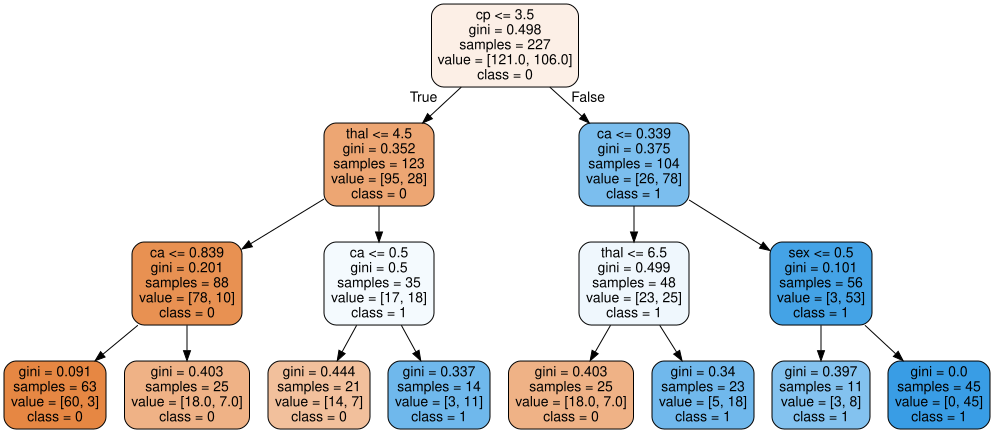

In [17]:
plot_data = export_graphviz(gridcv.best_estimator_,
                            out_file=None,
                            filled=True,
                            rounded=True,
                            feature_names=data.columns[:-1],
                            class_names=['0', '1'])

graph = graphviz.Source(plot_data)
graph

## Bagged decision trees
* Bagging classifier ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html))

In [18]:
clf = DecisionTreeClassifier()

## Random forest classifier
* Random forest ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html))

In [20]:
Clf = RandomForestClassifier()

#### Exercise
1. Study the hyperparameters of three models: [Decision tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html), [Bagged Decision Trees](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) and [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
2. For each model, use pipeline+grid search cross-validation across multiple hyperparameters to find the best model.
* Decision tree: choose at least 3 hyperparameters
* Bagged decision trees: choose at least 3 hyperparameters
* Random forest: choose at least 3 hyperparameters
3. For each model, compute the `f1_macro` and `accuracy` score on the test set.
* What is your best model?
* Plot the best tree model
* What hyperparameters did you choose? (explain in words, not in `sklearn's` parameter name)
* What are the best values of your hyperparameters?

In [30]:
# Decision Tree + Grid Search
pipe_dt = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", DecisionTreeClassifier(random_state=42))
])

param_dt = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

gs_dt = GridSearchCV(
    pipe_dt, param_dt,
    scoring="f1_macro",
    cv=5
)

gs_dt.fit(X_train, y_train)

y_pred_dt = gs_dt.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt, average="macro")


In [28]:
# Bagged Decision Trees + Grid Search
pipe_bag = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

param_bag = {
    "model__n_estimators": [50, 100, 200],
    "model__max_samples": [0.6, 0.8, 1.0],
    "model__estimator__max_depth": [None, 5, 10]
}

gs_bag = GridSearchCV(
    pipe_bag,
    param_bag,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

gs_bag.fit(X_train, y_train)

y_pred_bag = gs_bag.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score

bag_acc = accuracy_score(y_test, y_pred_bag)
bag_f1 = f1_score(y_test, y_pred_bag, average="macro")


In [29]:
# Random Forest + Grid Search
pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestClassifier(random_state=42))
])

param_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

gs_rf = GridSearchCV(
    pipe_rf, param_rf,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

gs_rf.fit(X_train, y_train)

y_pred_rf = gs_rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average="macro")


In [31]:
# Compare models
print("Decision Tree  | Acc:", dt_acc,  "| F1:", dt_f1)
print("Bagged Trees   | Acc:", bag_acc, "| F1:", bag_f1)
print("Random Forest  | Acc:", rf_acc,  "| F1:", rf_f1)

Decision Tree  | Acc: 0.8552631578947368 | F1: 0.850900659889424
Bagged Trees   | Acc: 0.8157894736842105 | F1: 0.8137254901960784
Random Forest  | Acc: 0.8026315789473685 | F1: 0.7984084880636605


In [32]:
best_model = max(
    [("Decision Tree", dt_f1),
     ("Bagged Trees", bag_f1),
     ("Random Forest", rf_f1)],
    key=lambda x: x[1]
)

print("Best model:", best_model[0])

Best model: Decision Tree


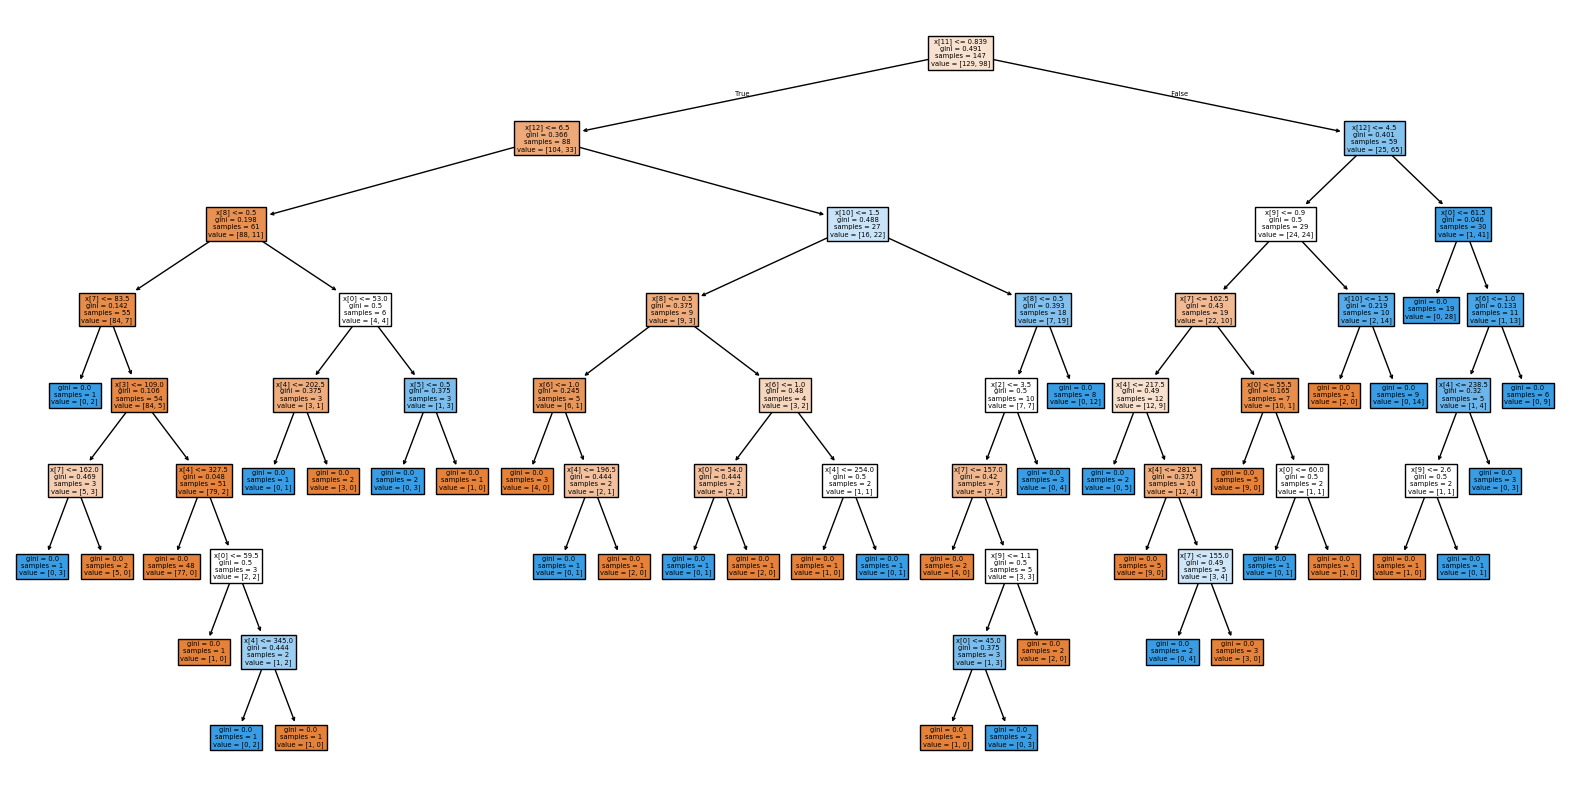

In [36]:
# Plot best tree (from Random Forest)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

best_rf = gs_rf.best_estimator_.named_steps["model"]

plt.figure(figsize=(20,10))
plot_tree(best_rf.estimators_[0], filled=True)
plt.show()


Best Model คือ Random Forest เพราะให้ค่า f1_macro สูงสุด ลด overfitting ได้ดีที่สุดและใช้ทั้ง bagging + random feature selection